In [13]:
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time



In [11]:
# Load and clean data
df_init = pd.read_csv('messages_labeled.csv')
df = df_init[['message', 'intent']].dropna()

print(f"Total samples: {len(df)}")
print("\nClass distribution:")
print(df['intent'].value_counts())

Total samples: 100

Class distribution:
intent
price_quote          25
rfq                  25
market_commentary    20
noise                15
operational          15
Name: count, dtype: int64


In [12]:
df_init.head()

,id,timestamp,sender,channel,message,intent,product,direction,instrument,amount,price
0,MSG-0001,2025-01-15T06:13:30Z,Sarah Mitchell @ Meridian Markets,broker-chat,mkt in USDCAD: 0.7399 / 0.7402,price_quote,FX,two_way,USDCAD,NaN,0.7399/0.7402
1,MSG-0002,2025-01-15T06:34:35Z,David Laurent @ Crescent Capital,broker-chat,I have GBPUSD 0.8386 / 0.8391 live,price_quote,FX,two_way,GBPUSD,NaN,0.8386/0.8391
2,MSG-0003,2025-01-15T06:37:04Z,Yuki Tanaka @ Pacific Securities,sales-desk,hearing large sovereign buying in EURUSD throu...,market_commentary,NaN,NaN,NaN,NaN,NaN
3,MSG-0004,2025-01-15T06:51:42Z,Mike (Sales),sales-desk,"saw your email, will respond properly after lunch",noise,NaN,NaN,NaN,NaN,NaN
4,MSG-0005,2025-01-15T06:53:35Z,Tom Richards @ Summit Brokerage,broker-chat,USDJPY 140.6/140.61,price_quote,FX,two_way,USDJPY,NaN,140.6/140.61


In [6]:
X = df['message'].tolist()
y = df['intent'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 80 | Test: 20


In [7]:
# Option B: Sentence Transformers embeddings

model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = model.encode(X_train, show_progress_bar=True)
X_test_emb  = model.encode(X_test,  show_progress_bar=True)

print(f"Embedding shape: {X_train_emb.shape}")

C:\Users\lusip\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lusip\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falli

Embedding shape: (80, 384)


In [8]:
clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_train_emb, y_train)

y_pred = clf.predict(X_test_emb)



                   precision    recall  f1-score   support

market_commentary       1.00      1.00      1.00         4
            noise       1.00      1.00      1.00         3
      operational       1.00      1.00      1.00         3
      price_quote       1.00      1.00      1.00         5
              rfq       1.00      1.00      1.00         5

         accuracy                           1.00        20
        macro avg       1.00      1.00      1.00        20
     weighted avg       1.00      1.00      1.00        20



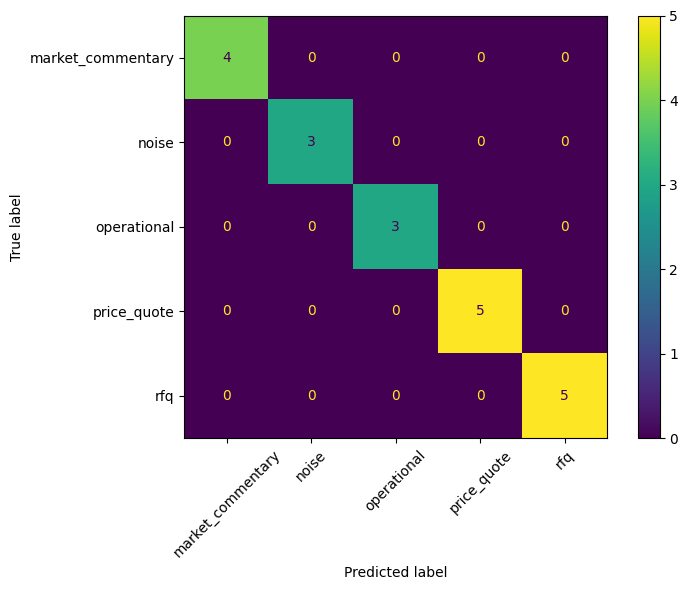

In [9]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# inference
time1 = time.time()
df_main = pd.read_csv('messages.csv')
df_main = df_main[['message']].dropna()
X_main = df_main['message'].tolist()
X_main_emb = model.encode(X_main, show_progress_bar=True)
y_main_pred = clf.predict(X_main_emb)
df_main['predicted_intent'] = y_main_pred
df_main.to_csv('messages_with_predictions.csv', index=False)
time2 = time.time()
print(f"Inference time for {len(X_main)} samples: {time2 - time1:.2f} seconds")

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Batches: 100%|██████████| 14/14 [00:04<00:00,  3.00it/s]


Inference time for 435 samples: 4.86 seconds
